In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy
from dask.distributed import Client
from pathlib import Path

In [2]:
base_path = "/gxfs_work/geomar/smomw122/2025_fucus-dispersal/output/Trajectories/"
experiment_type = "surface_stokes"

In [3]:
zarr_stores = sorted(Path(base_path).glob(f"{experiment_type}/????/*.zarr"))
len(zarr_stores)

56

In [4]:
zarr_stores = zarr_stores[::41]

In [5]:
ds = xr.open_mfdataset(zarr_stores, engine="zarr", combine="nested", concat_dim="trajectory")
ds = ds.assign_coords(trajectory=np.arange(ds.sizes["trajectory"]))
ds

<xarray.Dataset> Size: 44GB
Dimensions:          (trajectory: 174400, obs: 5274)
Coordinates:
  * obs              (obs) int32 21kB 0 1 2 3 4 5 ... 5269 5270 5271 5272 5273
  * trajectory       (trajectory) int64 1MB 0 1 2 3 ... 174397 174398 174399
Data variables:
    age_sec          (trajectory, obs) float32 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    cell_ID          (trajectory, obs) float32 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    lat              (trajectory, obs) float64 7GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    lon              (trajectory, obs) float64 7GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    max_age_sec      (trajectory, obs) float32 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    time             (trajectory, obs) datetime64[ns] 7GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    velocity_factor  (trajectory, obs) float32 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    z                (trajectory, obs) float64 7GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_BSHmax_age_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [6]:
ds = ds.assign(
    landseed=(
        (ds.lon.diff("obs").isel(obs=0, drop=True) == 0)
        & (ds.lat.diff("obs").isel(obs=0, drop=True) == 0)
    )
)
ds = ds.where(~ds.landseed)
ds

<xarray.Dataset> Size: 44GB
Dimensions:          (trajectory: 174400, obs: 5274)
Coordinates:
  * obs              (obs) int32 21kB 0 1 2 3 4 5 ... 5269 5270 5271 5272 5273
  * trajectory       (trajectory) int64 1MB 0 1 2 3 ... 174397 174398 174399
Data variables:
    age_sec          (trajectory, obs) float32 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    cell_ID          (trajectory, obs) float32 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    lat              (trajectory, obs) float64 7GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    lon              (trajectory, obs) float64 7GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    max_age_sec      (trajectory, obs) float32 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    time             (trajectory, obs) datetime64[ns] 7GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    velocity_factor  (trajectory, obs) float32 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    z                (trajectory, obs) float64 7GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
    landseed         (trajectory) float64 1MB dask.array<chunksize=(10000,), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_BSHmax_age_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [7]:
client = Client(ip="0.0.0.0", n_workers=4)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://134.245.3.59:8787/status,
Dashboard: http://134.245.3.59:8787/status,Workers: 4
Total threads: 32,Total memory: 192.00 GiB
Status: running,Using processes: True
Comm: tcp://134.245.3.59:39955,Workers: 4
Dashboard: http://134.245.3.59:8787/status,Total threads: 32
Started: Just now,Total memory: 192.00 GiB
Comm: tcp://134.245.3.59:34569,Total threads: 8
Dashboard: http://134.245.3.59:43233/status,Memory: 48.00 GiB
Nanny: tcp://134.245.3.59:40223,


In [8]:
from xhistogram.xarray import histogram as xhist

In [9]:
lon_bds = (ds.lon.min().compute().data[()], ds.lon.max().compute().data[()])
lat_bds = (ds.lat.min().compute().data[()], ds.lat.max().compute().data[()])

In [10]:
lon_bins = np.linspace(*lon_bds, 101)
lat_bins = np.linspace(*lat_bds, 101)

In [11]:
hst = xhist(
    ds.lon, ds.lat,
    bins=[lon_bins, lat_bins],
    dim=["trajectory"],
).rename({"lon_bin": "lon", "lat_bin": "lat"})

hst = hst.compute()

hst

<xarray.DataArray 'histogram_lon_lat' (obs: 5274, lon: 200, lat: 200)> Size: 2GB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]])
Coordinates:
  * obs      (obs) int32 21kB 0 1 2 3 4 5 6 ... 5268 5269 5270 5271 5272 5273
  * lon      (lon) float64 2kB -2.641 -2.477 -2.312 -2.147 ... 29.83 30.0 30.16
  * lat      (lat) float64 2kB 53.66 53.72 53.78 53.84 ... 65.67 65.74 65.8

/opt/conda/lib/python3.11/site-packages/xarray/core/computation.py:831: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


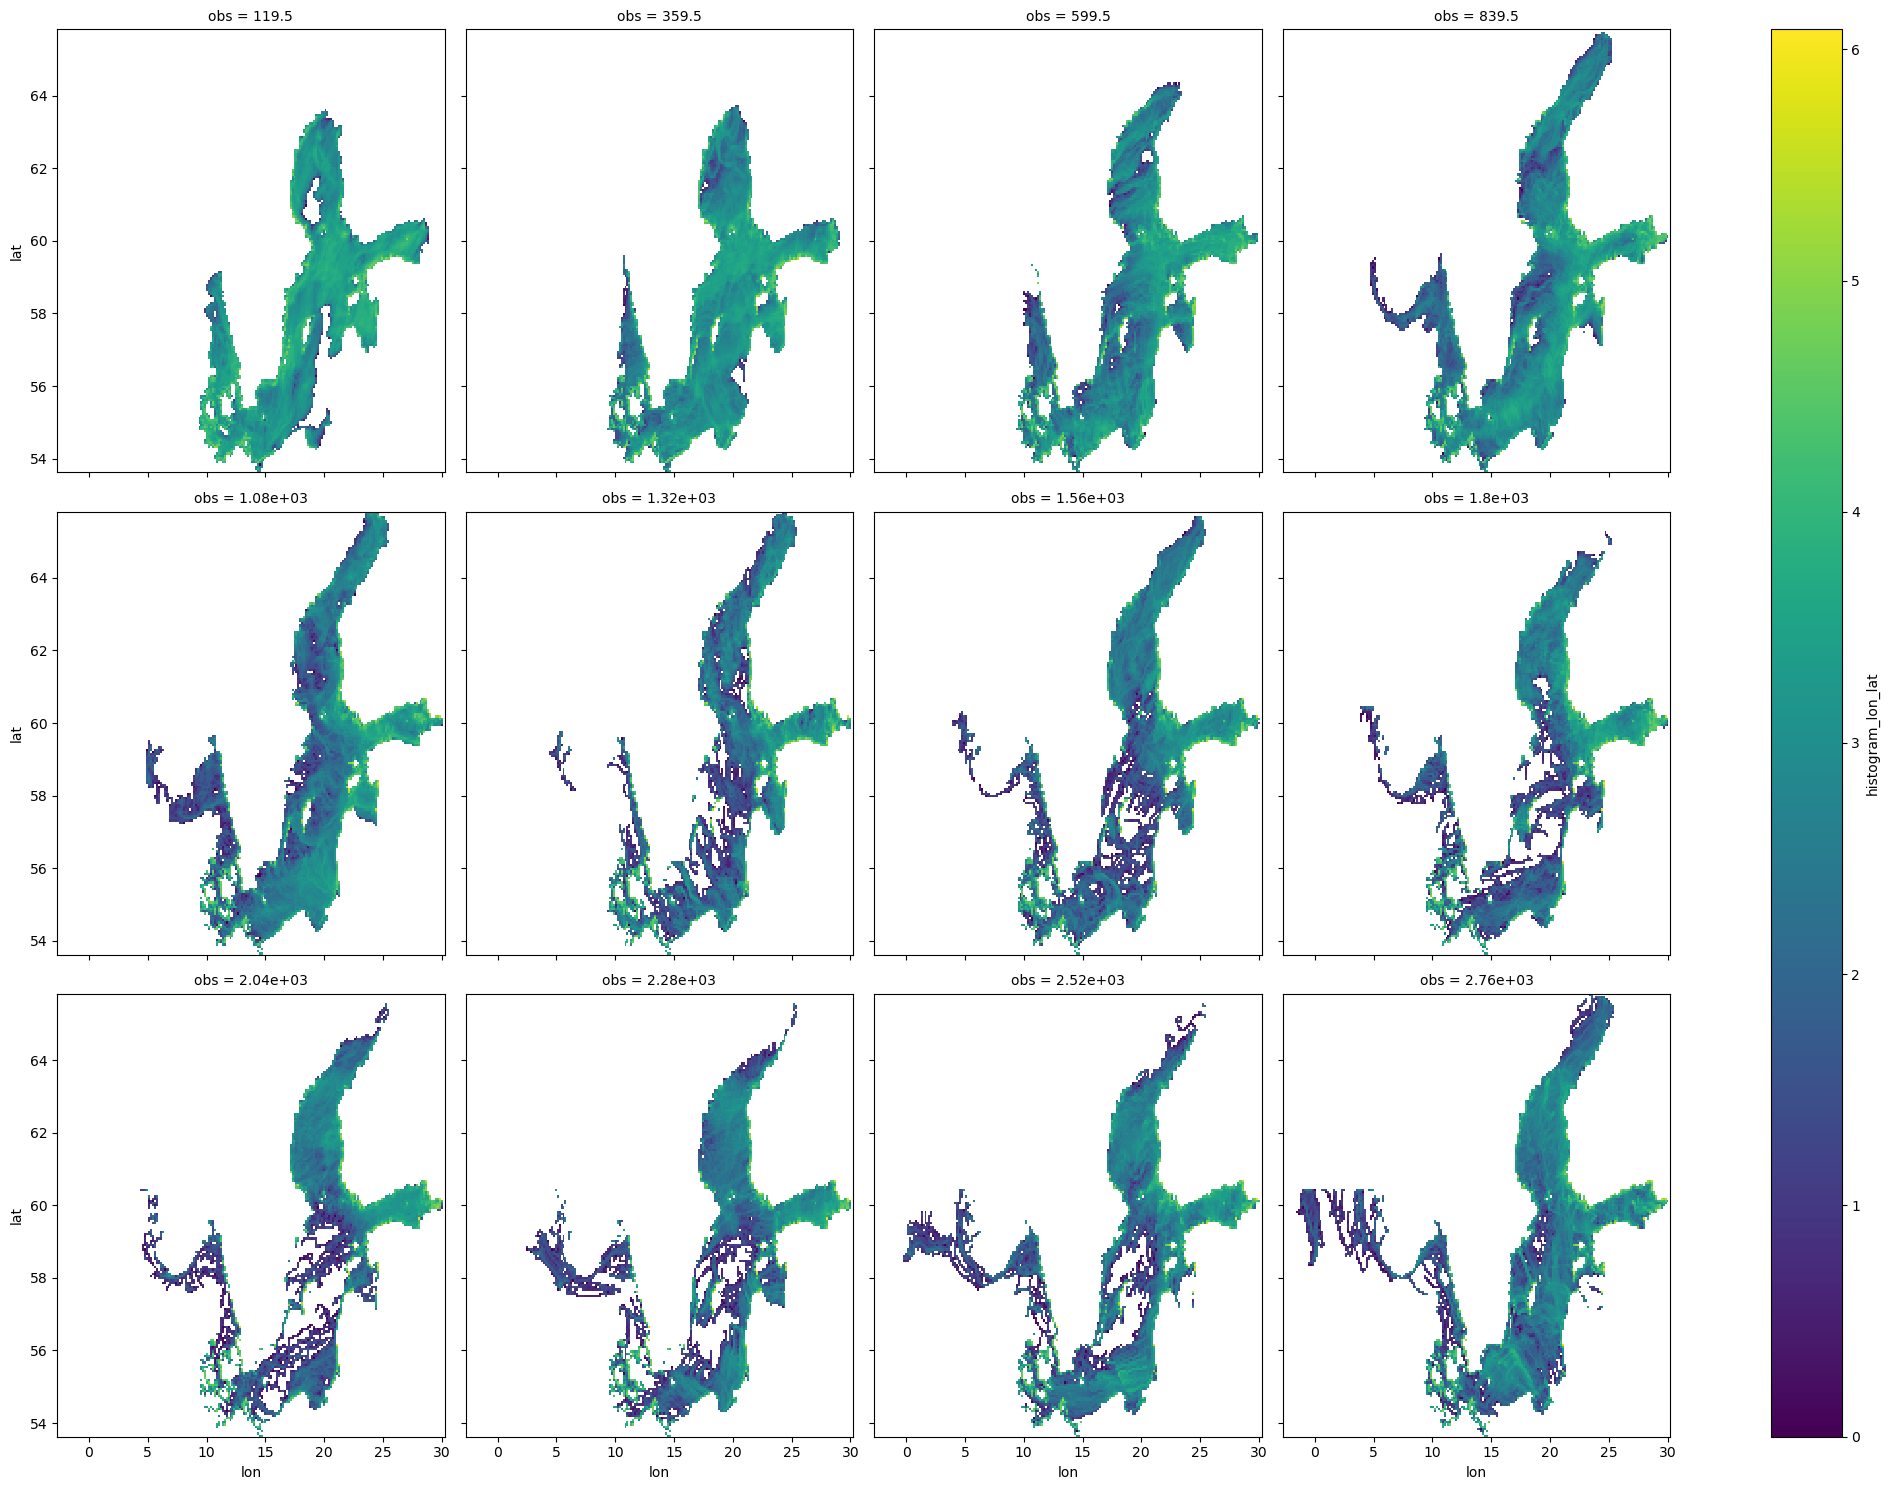

In [12]:
np.log10(hst.where(hst > 0).coarsen(obs=240, boundary="trim").sum()).isel(obs=slice(None, 12)).plot(x="lon", y="lat", col="obs", col_wrap=4, size=5)

In [13]:
fast = ((ds.lon.diff("obs") ** 2 + ds.lat.diff("obs") ** 2) ** 0.5).max().compute()

In [14]:
fast

<xarray.DataArray ()> Size: 8B
array(0.11307262)

In [15]:
slow = fast / 10_000
slow

<xarray.DataArray ()> Size: 8B
array(1.13072617e-05)

In [16]:
maybe_beached = ((ds.lon.diff("obs") ** 2 + ds.lat.diff("obs") ** 2) ** 0.5) < slow
maybe_beached.mean().compute()

<xarray.DataArray ()> Size: 8B
array(0.38722742)

In [17]:
hst_mb = xhist(
    ds.where(maybe_beached).lon, ds.where(maybe_beached).lat, 
    bins=[lon_bins, lat_bins],
    dim=["trajectory"],
).rename({"lon_bin": "lon", "lat_bin": "lat"})

hst_mb = hst_mb.compute()

<xarray.DataArray 'histogram_lon_lat' (obs: 5273, lon: 200, lat: 200)> Size: 2GB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]])
Coordinates:
  * obs      (obs) int32 21kB 1 2 3 4 5 6 7 ... 5268 5269 5270 5271 5272 5273
  * lon      (lon) float64 2kB -2.641 -2.477 -2.312 -2.147 ... 29.83 30.0 30.16
  * lat      (lat) float64 2kB 53.66 53.72 53.78 53.84 ... 65.67 65.74 65.8

/opt/conda/lib/python3.11/site-packages/xarray/core/computation.py:831: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


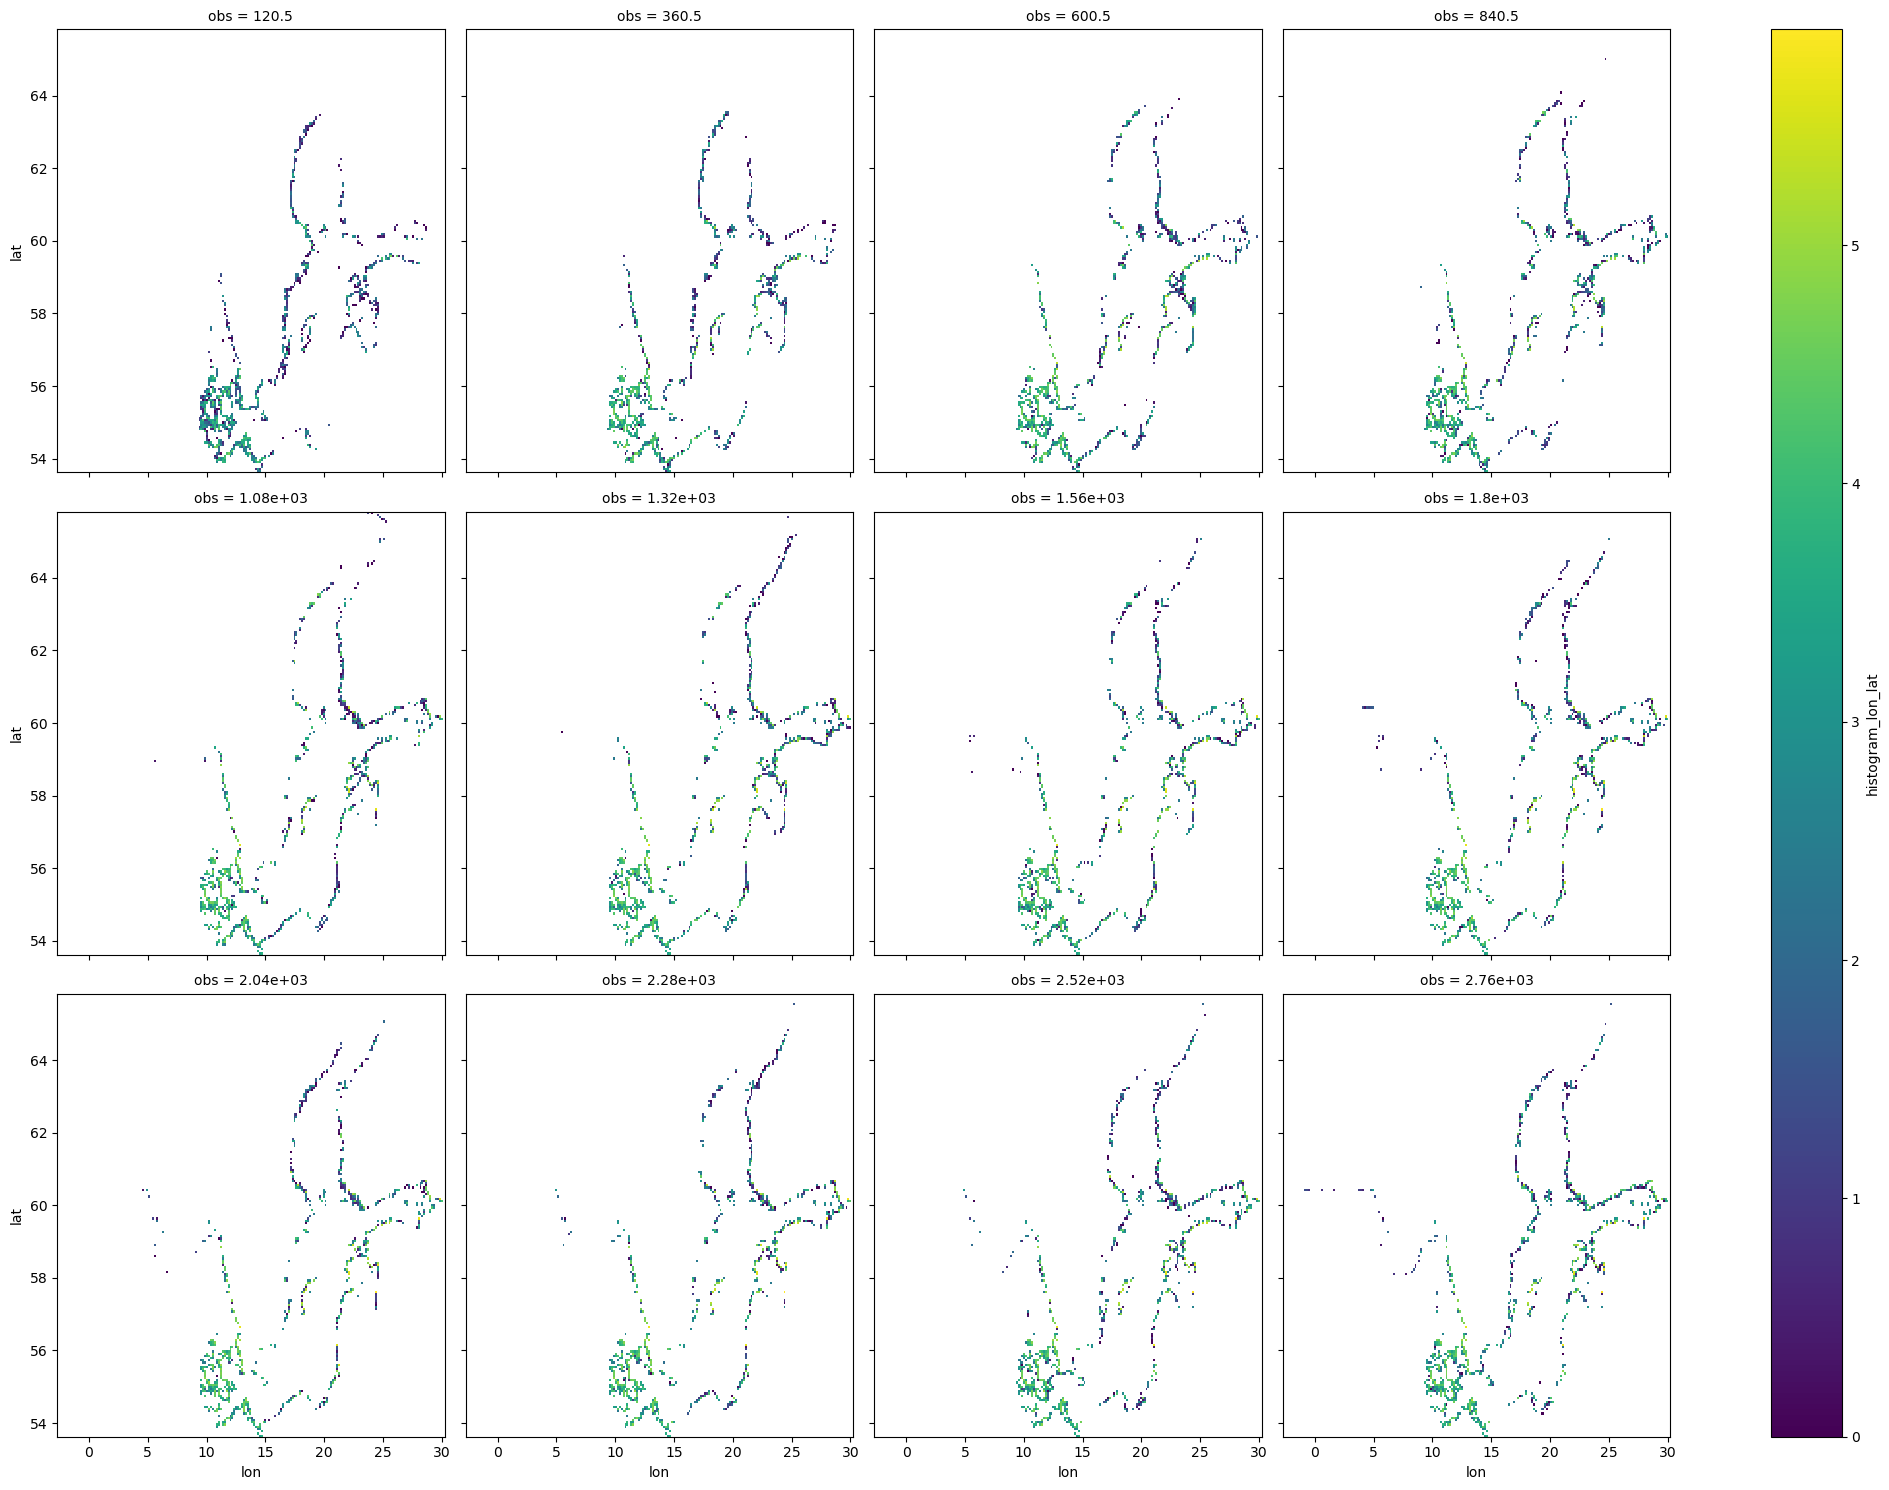

In [18]:
np.log10(hst_mb.where(hst_mb > 0).coarsen(obs=240, boundary="trim").sum()).isel(obs=slice(None, 12)).plot(x="lon", y="lat", col="obs", col_wrap=4, size=5)

In [19]:
maybe_beached_frac = maybe_beached.mean("obs").compute()


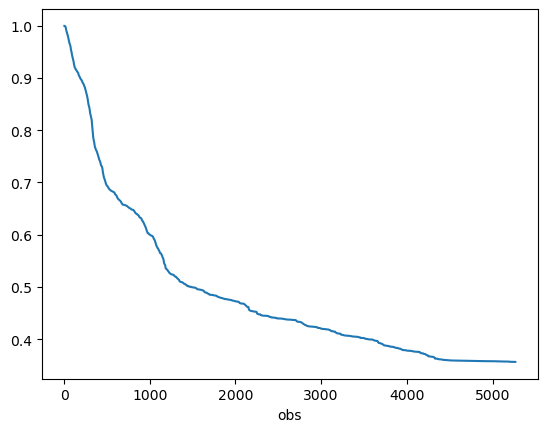

In [27]:
(~maybe_beached.coarsen(obs=6, boundary="trim").all()).astype(int).cumprod("obs").mean("trajectory").plot()

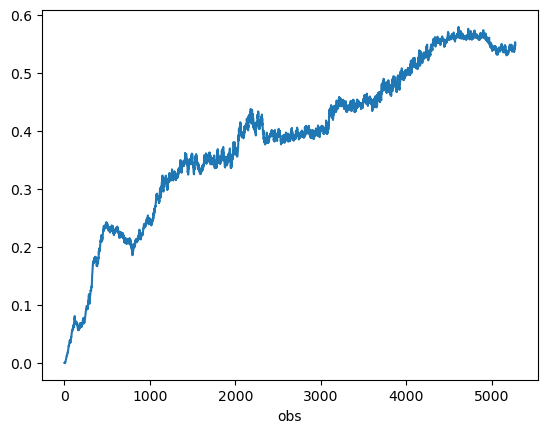

In [20]:
maybe_beached.mean("trajectory").plot()

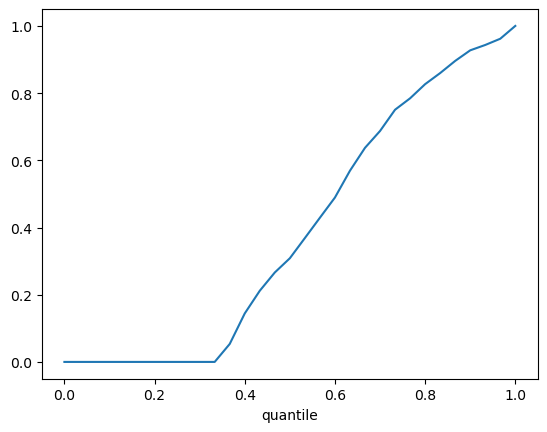

In [21]:
maybe_beached_frac.quantile(np.linspace(0, 1, 31)).plot()